# Day 26 - Customer Categorical Independence Test

## 분석 목적

VIP 여부와 retention_priority 여부의 관계를
교차표와 카이제곱 독립성 검정을 이용해 분석한다.

실제 관측빈도와 두 변수가 독립일 때 예상되는 기대빈도를 비교하고,
p-value뿐 아니라 기대빈도 조건도 함께 확인한다.

관측된 연관성을 인과관계로 해석하지 않는다.

## 분석 질문

1. VIP 고객과 Non-VIP 고객의 retention 분포는 어떻게 다른가?
2. VIP 여부와 retention 여부가 독립이라고 가정하면 각 조합의 기대빈도는 얼마인가?
3. 실제 관측빈도와 기대빈도의 차이는 어느 정도인가?
4. 카이제곱 독립성 검정 결과는 무엇인가?
5. 기대빈도는 카이제곱 검정을 적용하기에 충분한가?
6. 관측된 연관성을 인과관계로 해석할 수 있는가?

## 가설

### 귀무가설 H0

VIP 여부와 retention_priority 여부는 서로 독립이다.

### 대립가설 H1

VIP 여부와 retention_priority 여부는 서로 독립이 아니다.

### 유의수준

alpha = 0.05

p-value가 alpha보다 작으면 귀무가설을 기각한다.

p-value가 alpha 이상이면
귀무가설을 기각하지 못한다.

다만 카이제곱 검정에서는
p-value뿐 아니라 기대빈도가 너무 작지 않은지도 확인해야 한다.

In [1]:
# 라이브러리와 경로
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


project_root = Path.cwd().parent

input_path = (
    project_root
    / "outputs"
    / "customer_order_mini_project.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(input_path)
print(input_path.exists())

d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
True


In [2]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.shape
)

print(
    df.head()
)

(30, 18)
   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          

In [3]:
# 필요한 열 확인
print(
    df[
        [
            "grade",
            "management_action"
        ]
    ].head()
)

print(
    df[
        [
            "grade",
            "management_action"
        ]
    ].isna().sum()
)

  grade   management_action
0   VIP  retention_priority
1   VIP  retention_priority
2  GOLD  retention_priority
3   VIP  retention_priority
4   VIP  retention_priority
grade                0
management_action    0
dtype: int64


## 분석용 사건 정의

Day 22에서 사용했던 사건 정의를 그대로 사용한다.

VIP 여부:

grade == "VIP"

Retention 여부:

management_action == "retention_priority"

새로운 분류 기준을 만들지 않고
기존 분석 흐름을 이어간다.

In [4]:
# Boolean 변수 생성
df[
    "is_vip"
] = (
    df[
        "grade"
    ]
    == "VIP"
)

df[
    "is_retention"
] = (
    df[
        "management_action"
    ]
    == "retention_priority"
)

print(
    df[
        [
            "grade",
            "management_action",
            "is_vip",
            "is_retention",
        ]
    ].head()
)

  grade   management_action  is_vip  is_retention
0   VIP  retention_priority    True          True
1   VIP  retention_priority    True          True
2  GOLD  retention_priority   False          True
3   VIP  retention_priority    True          True
4   VIP  retention_priority    True          True


In [5]:
# 각 사건의 빈도 확인
print(
    "VIP 여부:"
)

print(
    df[
        "is_vip"
    ].value_counts()
)

print(
    "Retention 여부:"
)

print(
    df[
        "is_retention"
    ].value_counts()
)

VIP 여부:
is_vip
False    22
True      8
Name: count, dtype: int64
Retention 여부:
is_retention
False    21
True      9
Name: count, dtype: int64


## 교차표

value_counts()는 하나의 변수에
각 범주가 몇 번 나타나는지 확인할 때 사용했다.

이번에는

VIP 여부 × Retention 여부

두 변수 조합별 고객 수가 필요하다.

따라서 두 범주형 변수의 조합별 빈도를 계산하는
pd.crosstab()을 사용한다.

In [6]:
# 관측빈도 교차표
observed_df = pd.crosstab(
    df[
        "is_vip"
    ],
    df[
        "is_retention"
    ]
)

print(
    observed_df
)

is_retention  False  True 
is_vip                    
False            20      2
True              1      7


In [7]:
# 관측빈도 저장
observed_output_path = (
    output_dir
    / "customer_vip_retention_observed.csv"
)

observed_df.to_csv(
    observed_output_path
)

print(
    observed_output_path.exists()
)

True


## 관측빈도와 기대빈도

관측빈도는 실제 데이터의 고객 수다.

기대빈도는

VIP 여부와 Retention 여부가 서로 독립이라고 가정했을 때
각 조합에 예상되는 고객 수다.

카이제곱 검정은 이 두 빈도의 차이를 이용한다.

In [8]:
# 카이제곱 검정
chi2, p_value, dof, expected = (
    chi2_contingency(
        observed_df
    )
)

print(
    "chi-square:",
    chi2
)

print(
    "p-value:",
    p_value
)

print(
    "degrees of freedom:",
    dof
)

print(
    "expected frequency:"
)

print(
    expected
)

chi-square: 13.644480519480519
p-value: 0.00022088969423129367
degrees of freedom: 1
expected frequency:
[[15.4  6.6]
 [ 5.6  2.4]]


In [9]:
# 기대빈도 표 만들기
expected_df = pd.DataFrame(
    expected,
    index=observed_df.index,
    columns=observed_df.columns
)

print(
    expected_df
)

is_retention  False  True 
is_vip                    
False          15.4    6.6
True            5.6    2.4


In [10]:
# 기대빈도 저장
expected_output_path = (
    output_dir
    / "customer_vip_retention_expected.csv"
)

expected_df.to_csv(
    expected_output_path
)

print(
    expected_output_path.exists()
)

True


In [14]:
# 작은 기대빈도 확인
small_expected_count = (
    (
        expected_df < 5
    )
    .sum()
    .sum()
)

print(
    "5보다 작은 기대빈도 셀 수:",
    small_expected_count
)

5보다 작은 기대빈도 셀 수: 1


In [15]:
# 유의수준과 검정 판단
alpha = 0.05

if p_value < alpha:
    test_decision = (
        "reject_null_hypothesis"
    )
else:
    test_decision = (
        "fail_to_reject_null_hypothesis"
    )

print(
    "유의수준:",
    alpha
)

print(
    "검정 판단:",
    test_decision
)

유의수준: 0.05
검정 판단: reject_null_hypothesis


In [16]:
# 검정 결과 요약 표
result_df = pd.DataFrame(
    {
        "metric": [
            "chi_square",
            "p_value",
            "degrees_of_freedom",
            "alpha",
            "small_expected_count",
        ],
        "value": [
            chi2,
            p_value,
            dof,
            alpha,
            small_expected_count,
        ],
    }
)

print(
    result_df
)

                 metric      value
0            chi_square  13.644481
1               p_value   0.000221
2    degrees_of_freedom   1.000000
3                 alpha   0.050000
4  small_expected_count   1.000000


In [17]:
# 결과 저장
result_output_path = (
    output_dir
    / "customer_vip_retention_chi_square_result.csv"
)

result_df.to_csv(
    result_output_path,
    index=False
)

print(
    result_output_path.exists()
)

True


## 교차표 시각화

카이제곱 검정의 p-value만 보지 않고
각 고객 그룹의 실제 빈도가 어떻게 다른지 그래프로 확인한다.

그래프는 검정을 대신하는 것이 아니라
검정 결과를 해석하기 위한 보조 자료다.

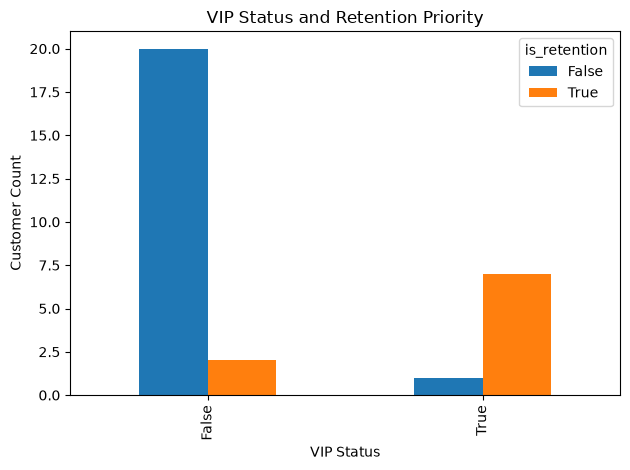

In [18]:
# 교차표 그래프
figure_path = (
    output_dir
    / "customer_vip_retention_count.png"
)

observed_df.plot.bar()

plt.title(
    "VIP Status and Retention Priority"
)

plt.xlabel(
    "VIP Status"
)

plt.ylabel(
    "Customer Count"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## t검정과 카이제곱 검정 구분

### 독립표본 t검정

질문:

두 독립 집단의 평균이 다른가?

예:

VIP와 Non-VIP의 평균 주문 수


### 대응표본 t검정

질문:

같은 대상의 전후 평균이 다른가?

예:

같은 고객의 캠페인 전후 구매액


### 카이제곱 독립성 검정

질문:

두 범주형 변수의 빈도 분포가 서로 연관되는가?

예:

VIP 여부와 Retention 여부


검정 이름을 먼저 고르는 것이 아니라
변수의 종류와 데이터 관계를 먼저 확인한다.

## 핵심 결과

### 1. 관측빈도

VIP 고객의 Retention 분포: 7

Non-VIP 고객의 Retention 분포: 2

### 2. 기대빈도

VIP 여부와 Retention 여부가 독립이라고 가정했을 때의
기대빈도를 계산했다.

5보다 작은 기대빈도 셀 수: 1

### 3. 카이제곱 독립성 검정

chi-square: 13.6445

p-value: 0.0002

자유도: 1

유의수준: 0.05

판단: 귀무가설 기각

### 4. 결과 해석

VIP 여부와 Retention 여부가 독립이라는 유의미한 통계적 수치를 확인하지 못했다.

### 5. 검정 조건 주의

현재 데이터는 고객 수가 30명으로 작다.

기대빈도가 작은 셀이 존재한다면
카이제곱 근사 결과를 강하게 해석하지 않는다.

작은 2×2 교차표에서는
Fisher 정확검정과 같은 다른 방법도 고려할 수 있다.


### 6. 인과관계 한계

VIP 여부와 Retention 여부의 연관성이 관측되더라도
VIP 등급이 Retention을 발생시킨다고 결론 내리지 않는다.

고객 등급 자체가 기존 주문 활동을 기준으로
부여되었을 가능성도 있기 때문이다.